# Lesson 2: Conditional Edges

## *First Real Graph Intelligence*

---

### Why This Matters

In Lesson 1, our graph was a straight conveyor belt: `START -> chatbot -> END`. Every input got the exact same treatment. That is like a factory with one assembly line and no quality control branching.

Real systems need to **make decisions**. A conditional edge gives your graph the power to inspect the current situation and choose a different path.

---

### The Mental Model

> **Think of a doctor's triage desk in an emergency room.**
>
> Every patient walks in the same door. But the triage nurse checks their symptoms and sends them down different hallways:
> - Chest pain goes to **cardiology**
> - Broken bone goes to **orthopedics**  
> - Mild fever goes to **general care**
>
> The nurse *inspects* the patient (reads the State) and *decides* which department (next node) they go to.
> That decision is a **conditional edge**.

---

### What We Will Build

| Order Amount | Path Taken | Why |
|:---|:---|:---|
| Under $100 | Auto-approved, ships immediately | Low risk, no human needed |
| $100 or above | Routed through fraud check | High value = higher risk |

**Architecture:**

```
START -> evaluate_order -> [conditional check]
                              |
                   +----------+----------+
                   |                     |
            auto_approve           fraud_check
                   |                     |
                  END                   END
```

---

## Step 1: Setup

Same imports as Lesson 1. No new packages required.

In [17]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

---

## Step 2: Define State

Our State tracks order information. Think of it as a **clipboard** that every worker passes around. Each worker reads it, does their job, and writes their update.

| Field | Purpose |
|:---|:---|
| `order_id` | Reference number for the order |
| `order_amount` | How much the order costs |
| `status` | Current processing status |
| `message` | Human-readable result |

In [18]:
class State(TypedDict):
    order_id: str
    order_amount: float
    status: str
    message: str

---

## Step 3: Define the Nodes

Three workers, each with a distinct responsibility:

| Node | Role | Real-World Equivalent |
|:---|:---|:---|
| `evaluate_order` | Tags the order as low or high value | The triage nurse |
| `auto_approve` | Approves and ships immediately | Express checkout lane |
| `fraud_check` | Runs verification before approving | Security screening |

> **Key Insight**: The two downstream nodes do genuinely different work. Auto-approve is fast and cheap. Fraud check is slower but prevents costly chargebacks on large orders.

In [19]:
THRESHOLD = 100.0

def evaluate_order(state: State):
    """Looks at the order amount and tags it as low_value or high_value."""
    if state["order_amount"] < THRESHOLD:
        return {"status": "low_value"}
    else:
        return {"status": "high_value"}


def auto_approve(state: State):
    """Fast path: small orders get approved instantly, no questions asked."""
    return {
        "status": "approved",
        "message": f"Order {state['order_id']} (${state['order_amount']:.2f}) auto-approved. Shipping now."
    }


def fraud_check(state: State):
    """Careful path: large orders go through fraud verification first."""
    # In production this would call a fraud detection API
    is_suspicious = state["order_amount"] > 500  # simple rule for demo
    if is_suspicious:
        return {
            "status": "flagged",
            "message": f"Order {state['order_id']} (${state['order_amount']:.2f}) flagged for manual review."
        }
    else:
        return {
            "status": "approved",
            "message": f"Order {state['order_id']} (${state['order_amount']:.2f}) passed fraud check. Approved."
        }

---

## Step 4: The Routing Function

> **This is the key new concept.**
>
> A routing function inspects the State and returns the *name* of the next node.
> Think of it like a switchman at a railway junction - he reads the tag on the cargo car and flips the switch to the correct track.

**Rules:**
- Must return a `str` that matches a registered node name
- Runs *after* the source node completes
- Has access to the full current State
- Does NOT appear as a node in the graph diagram (it lives inside the edge itself)

In [20]:
def route_by_value(state: State) -> str:
    """Decides which path the order takes based on the evaluation."""
    if state["status"] == "low_value":
        return "auto_approve"
    else:
        return "fraud_check"

---

## Step 5: Build the Graph with Conditional Edge

Here is where it all comes together. Instead of a fixed edge after `evaluate_order`, we use `add_conditional_edges`.

> **Translation**: "After evaluate_order finishes, call `route_by_value` to figure out where to go next."

The `path_map` parameter explicitly lists all possible destinations. This serves two purposes:
1. **Validation** - LangGraph warns you if the routing function returns an unexpected value
2. **Visualization** - The graph renderer draws arrows to all listed targets

In [21]:
workflow = StateGraph(State)

# Register all nodes
workflow.add_node("evaluate_order", evaluate_order)
workflow.add_node("auto_approve", auto_approve)
workflow.add_node("fraud_check", fraud_check)

# Fixed edge: START always goes to evaluate_order
workflow.add_edge(START, "evaluate_order")

# Conditional edge: after evaluate_order, route_by_value decides the path
# The path_map tells the graph renderer which nodes are reachable from here
workflow.add_conditional_edges(
    "evaluate_order",
    route_by_value,
    {"auto_approve": "auto_approve", "fraud_check": "fraud_check"}
)

# Both paths lead to END
workflow.add_edge("auto_approve", END)
workflow.add_edge("fraud_check", END)

app = workflow.compile()

---

## Step 6: Test All Three Scenarios

Let us send three different orders and watch the graph take different routes:

| Test | Amount | Expected Path |
|:---|:---|:---|
| Small order | $45.99 | Auto-approved |
| Medium-large order | $250.00 | Fraud check -> Approved |
| Very large order | $1,200.00 | Fraud check -> Flagged |

In [22]:
# Test 1: Small order - takes the fast auto-approve path
result = app.invoke({"order_id": "ORD-001", "order_amount": 45.99, "status": "", "message": ""})
print(f"Status: {result['status']}")
print(f"Result: {result['message']}")
print("---")

Status: approved
Result: Order ORD-001 ($45.99) auto-approved. Shipping now.
---


In [23]:
# Test 2: Medium order - goes through fraud check, passes
result = app.invoke({"order_id": "ORD-002", "order_amount": 250.00, "status": "", "message": ""})
print(f"Status: {result['status']}")
print(f"Result: {result['message']}")
print("---")

# Test 3: Very large order - goes through fraud check, gets flagged
result = app.invoke({"order_id": "ORD-003", "order_amount": 1200.00, "status": "", "message": ""})
print(f"Status: {result['status']}")
print(f"Result: {result['message']}")

Status: approved
Result: Order ORD-002 ($250.00) passed fraud check. Approved.
---
Status: flagged
Result: Order ORD-003 ($1200.00) flagged for manual review.


---

## Step 7: Visualize the Graph

The rendered diagram shows the branching structure. Notice how `evaluate_order` fans out to two possible destinations via the conditional edge.

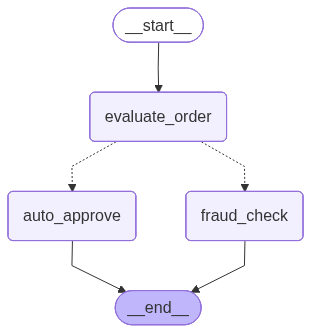

In [24]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

---

## Summary

### What We Built

A graph that **inspects before it acts**. Instead of blindly following a fixed path:

1. **Reads** the situation (inspects State - what is the order amount?)
2. **Decides** the route (routing function - high value or low value?)
3. **Executes** the appropriate path (conditional edge - auto-approve or fraud check)

---

### API Reference

| Method | Purpose |
|:---|:---|
| `add_conditional_edges(source, func, path_map)` | Add a decision point after a node |
| Routing function | Returns a node name as a string |
| `path_map` (dict) | Maps return values to node names for validation and rendering |

---

### Key Takeaways

> 1. A conditional edge turns your pipeline into a **decision tree**
> 2. The routing function is invisible in the diagram - it lives *inside* the edge
> 3. Different paths can have completely different logic, not just different text
> 4. Always provide a `path_map` for clear visualization and validation

---

**Next Lesson**: What if the graph needs to *loop back* and try again? Lesson 3 introduces loops - the retry/reason-act cycle.